<a href="https://colab.research.google.com/github/IshaanMhalgi1/mlassignments/blob/main/ass13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 13
Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method. Dataset Link: https://www.kaggle.com/datasets/uciml/iris

Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

print(f"Feature names: {iris.feature_names}")
print(f"Target names: {iris.target_names}")

df = pd.DataFrame(data=X, columns=iris.feature_names)
df['species'] = iris.target_names[y]
df

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


Removing Outliers

In [ ]:
df = df[df['sepal width (cm)'] < 4.0 ]

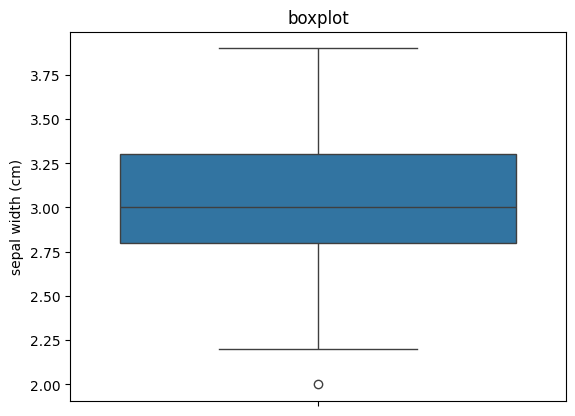

In [ ]:
sns.boxplot(df['sepal width (cm)'])
plt.title('boxplot')
plt.show()

K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
x = df.iloc[:,[0,3]].values
kmeans = KMeans(n_clusters = 2, init = 'k-means++',random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_predict = kmeans.fit_predict(X_scaled)

Applying Elbow Method

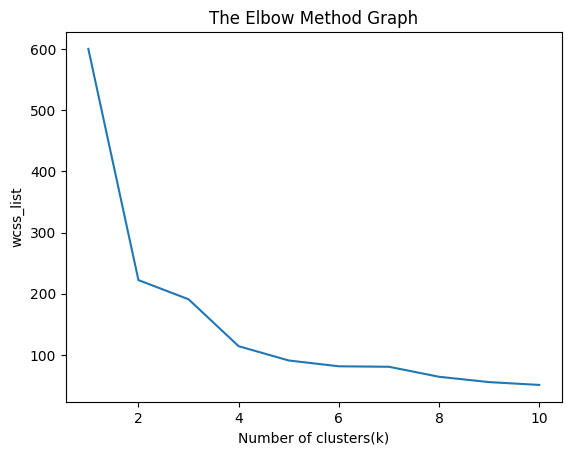

In [ ]:
wcss_list= []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state= 42)
    kmeans.fit(X_scaled)
    wcss_list.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss_list)
plt.title('The Elbow Method Graph')
plt.xlabel('Number of clusters(k)')
plt.ylabel('wcss_list')
plt.show()

Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score
sil = silhouette_score(X_scaled, y_predict)
print(sil)

0.5817500491982808


#Conclusion
Elbow Method is results in better prediction for K-Means Clustering